In [1]:
import pandas as pd
import numpy as np
import glob

# === 參數設定 ===
WINDOW_SIZE = 100
STRIDE = 50

# === 檔案路徑 ===
files = [
    "../data/raw/e0-bridge.csv",
    "../data/raw/e1-lake.csv",
    "../data/raw/e2-forest.csv",
    "../data/raw/e3-river.csv",
    "../data/raw/e4-garden.csv"
]

# === device mapping ===
device_to_label = {
    "RIOT-BLE-0": 0,
    "RIOT-BLE-1": 1,
    "RIOT-BLE-2": 2,
    "RIOT-BLE-3": 3
}

# === 儲存結果 ===
X = []
y = []

# === 處理每個環境 ===
for env_id, file in enumerate(files):

    df = pd.read_csv(file)

    # 時間排序（保險）
    df['ts'] = pd.to_datetime(df['ts'])
    df = df.sort_values('ts')

    # 每個 node 分開處理
    for device, label in device_to_label.items():

        df_node = df[df['device'] == device].copy()
        if len(df_node) < WINDOW_SIZE:
            continue

        # === 差分 ===
        df_node['rssi_diff'] = df_node['rssi'].diff()
        
        # === drop NaN ===
        df_node = df_node.dropna(subset=['rssi_diff'])
        # === normalization（每個 node 各自做）===
        y_min = df_node['rssi_diff'].min()
        y_max = df_node['rssi_diff'].max()

        if y_max - y_min == 0:
            continue

        df_node['rssi_norm'] = (df_node['rssi_diff'] - y_min) / (y_max - y_min)

        # === 轉成 numpy ===
        data = df_node['rssi_norm'].values

        # === 切 sequence ===
        for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
            seq = data[i:i+WINDOW_SIZE]

            X.append(seq)
            y.append(label)

# === 轉 numpy ===
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5932, 100)
y shape: (5932,)


In [2]:
# =========================
# Step 1: reshape for 1D CNN
# =========================
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# X: (6779, 100)
# y: (6779,)

X = X.astype(np.float32)
y = y.astype(np.int64)

# PyTorch Conv1d input: (batch, channels, length)
X = X[:, np.newaxis, :]   # -> (6779, 1, 100)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("X_train:", X_train_tensor.shape)
print("X_test :", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([4449, 1, 100])
X_test : torch.Size([1483, 1, 100])
y_train: torch.Size([4449])
y_test : torch.Size([1483])


In [3]:
# =========================
# Step 2: define 1D CNN model
# =========================
import torch.nn as nn

class CNN1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),#feature=1因種類只有rssi
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # 100 -> 50

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # 50 -> 25

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)    # 25 -> 12
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


num_classes = len(np.unique(y))
model = CNN1D(num_classes=num_classes)
print(model)

CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1536, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [4]:
# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [5]:
# =========================
# Step 4: training loop
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total

In [6]:
# =========================
# Step 5: run training
# =========================
num_epochs = 100

train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")


Epoch [1/100] Train Loss: 1.3321, Train Acc: 0.3383 | Test Loss: 1.2744, Test Acc: 0.3446
Epoch [2/100] Train Loss: 1.2154, Train Acc: 0.3871 | Test Loss: 1.1764, Test Acc: 0.3911
Epoch [3/100] Train Loss: 1.1677, Train Acc: 0.4163 | Test Loss: 1.1299, Test Acc: 0.4262
Epoch [4/100] Train Loss: 1.1113, Train Acc: 0.4579 | Test Loss: 1.0910, Test Acc: 0.4228
Epoch [5/100] Train Loss: 1.1026, Train Acc: 0.4588 | Test Loss: 1.0875, Test Acc: 0.4646
Epoch [6/100] Train Loss: 1.0425, Train Acc: 0.5026 | Test Loss: 1.0871, Test Acc: 0.4936
Epoch [7/100] Train Loss: 1.0232, Train Acc: 0.5356 | Test Loss: 0.9880, Test Acc: 0.5833
Epoch [8/100] Train Loss: 1.0085, Train Acc: 0.5428 | Test Loss: 1.0075, Test Acc: 0.5637
Epoch [9/100] Train Loss: 0.9701, Train Acc: 0.5723 | Test Loss: 1.0549, Test Acc: 0.5057
Epoch [10/100] Train Loss: 0.9412, Train Acc: 0.5727 | Test Loss: 0.8831, Test Acc: 0.5833


KeyboardInterrupt: 

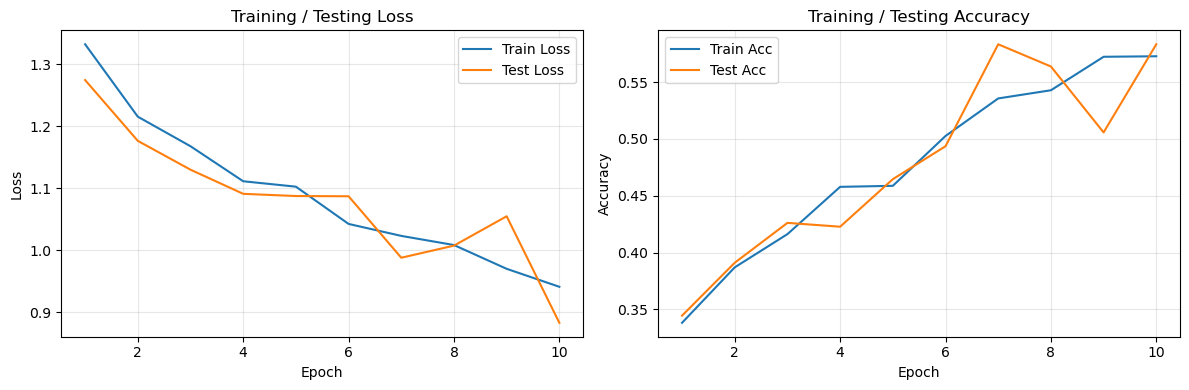

In [7]:
# =========================
# Step 5.5: plot training curves
# =========================
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Testing Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, test_accs, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training / Testing Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Step 6: prediction example
# =========================
model.eval()

with torch.no_grad():
    sample_x = X_test_tensor[:10].to(device)
    outputs = model(sample_x)
    preds = outputs.argmax(dim=1).cpu().numpy()

print("Pred:", preds)
print("True:", y_test[:10])

Pred: [0 0 0 0 2 0 2 2 3 3]
True: [0 0 0 0 0 0 3 2 3 0]


In [ ]:
# =========================
# Step 7: confusion matrix
# =========================
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(all_true, all_preds))

Confusion Matrix:
 [[329   6  80  76]
 [ 54 214 133   7]
 [  2  35 330  20]
 [ 29  15  91 274]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.67      0.73       491
           1       0.79      0.52      0.63       408
           2       0.52      0.85      0.65       387
           3       0.73      0.67      0.70       409

    accuracy                           0.68      1695
   macro avg       0.71      0.68      0.68      1695
weighted avg       0.72      0.68      0.68      1695

